In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression

import warnings
warnings.filterwarnings('ignore')

In [18]:
df = pd.read_csv("https://raw.githubusercontent.com/Laxminarayen/InceptezGenAI-Batch26/refs/heads/main/21.%20Polynomial%20Regression/handson/Salary_Experience_Dataset.csv")

In [19]:
df.head()

,years_experience,education_level,certifications,salary_lpa
0,9.38,2,2,22.96
1,13.46,1,2,23.48
2,11.64,0,3,20.78
3,3.38,2,3,14.55
4,4.50,1,1,13.11


In [20]:
df

,years_experience,education_level,certifications,salary_lpa
0,9.38,2,2,22.96
1,13.46,1,2,23.48
2,11.64,0,3,20.78
3,3.38,2,3,14.55
4,4.50,1,1,13.11
...,...,...,...,...
495,1.10,0,1,7.60
496,13.00,1,1,20.20
497,4.69,2,5,16.37
498,7.42,1,2,18.22


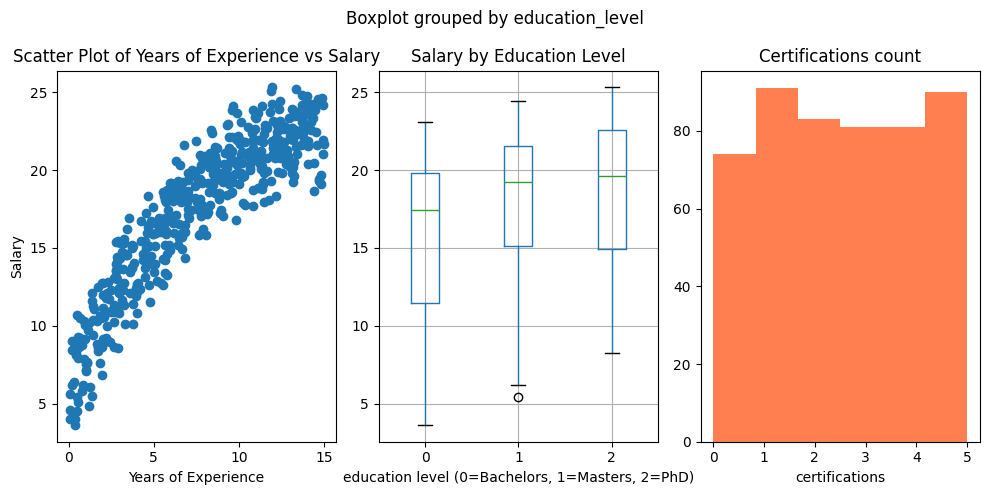

In [21]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 5))

axes[0].scatter(df['years_experience'], df['salary_lpa'])
axes[0].set_xlabel('Years of Experience')
axes[0].set_ylabel('Salary')
axes[0].set_title('Scatter Plot of Years of Experience vs Salary')

df.boxplot(column='salary_lpa', by='education_level', ax=axes[1])
axes[1].set_title('Salary by Education Level')
axes[1].set_xlabel('education level (0=Bachelors, 1=Masters, 2=PhD)')

axes[2].hist(df['certifications'], bins=6, color='coral')
axes[2].set_title('Certifications count')
axes[2].set_xlabel('certifications')

plt.tight_layout()
plt.show()

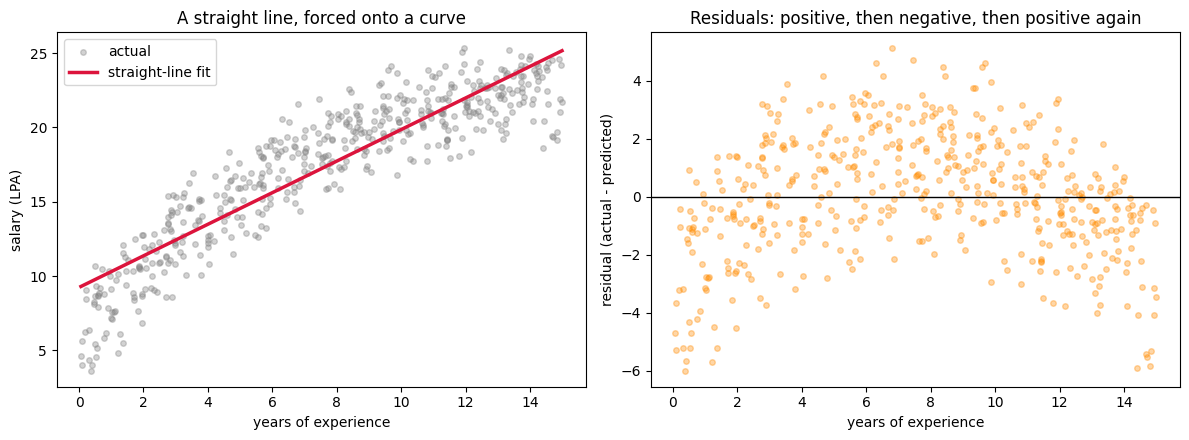

Linear model R2 (whole dataset): 0.8230

See the shape in the residuals? Positive early, dips negative in the middle, swings back
positive at the end — a genuine curve the line can't see, not random scatter.


In [22]:
linear_model = LinearRegression()
linear_model.fit(df[['years_experience']], df['salary_lpa'])

df['linear_pred'] = linear_model.predict(df[['years_experience']])
df['linear_residual'] = df['salary_lpa'] - df['linear_pred']

fig, axes = plt.subplots(1, 2, figsize=(12,4.5))

axes[0].scatter(df['years_experience'], df['salary_lpa'], alpha=0.35, s=16, color='gray', label='actual')
order = df.sort_values('years_experience')
axes[0].plot(order['years_experience'], order['linear_pred'], color='crimson', linewidth=2.5, label='straight-line fit')
axes[0].set_xlabel('years of experience')
axes[0].set_ylabel('salary (LPA)')
axes[0].set_title('A straight line, forced onto a curve')
axes[0].legend()

axes[1].scatter(df['years_experience'], df['linear_residual'], alpha=0.35, s=16, color='darkorange')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('years of experience')
axes[1].set_ylabel('residual (actual - predicted)')
axes[1].set_title('Residuals: positive, then negative, then positive again')

plt.tight_layout()
plt.show()

print(f"Linear model R2 (whole dataset): {r2_score(df['salary_lpa'], df['linear_pred']):.4f}")
print("\nSee the shape in the residuals? Positive early, dips negative in the middle, swings back")
print("positive at the end — a genuine curve the line can't see, not random scatter.")

In [23]:
df['exp2'] = df['years_experience'] ** 2
df['exp3'] = df['years_experience'] ** 3
df['exp4'] = df['years_experience'] ** 4
df['exp5'] = df['years_experience'] ** 5

df[['years_experience','exp2','exp3','exp4','salary_lpa']]

,years_experience,exp2,exp3,exp4,salary_lpa
0,9.38,87.9844,825.293672,7741.254643,22.96
1,13.46,181.1716,2438.569736,32823.148647,23.48
2,11.64,135.4896,1577.098944,18357.431708,20.78
3,3.38,11.4244,38.614472,130.516915,14.55
4,4.50,20.2500,91.125000,410.062500,13.11
...,...,...,...,...,...
495,1.10,1.2100,1.331000,1.464100,7.60
496,13.00,169.0000,2197.000000,28561.000000,20.20
497,4.69,21.9961,103.161709,483.828415,16.37
498,7.42,55.0564,408.518488,3031.207181,18.22


In [24]:
scaler = MinMaxScaler() #between 0-1
norm_cols = ['years_experience','education_level','certifications']
normalized = scaler.fit_transform(df[norm_cols])

In [26]:
df['ExpNorm'] = normalized[:,0]
df['EduNorm'] = normalized[:,1]
df['CertNorm'] = normalized[:,2]

In [27]:
exp_min, edu_min, cer_min = scaler.data_min_

In [34]:
exp_min

np.float64(0.06)

In [29]:
exp_max, edu_max, cer_max = scaler.data_max_

In [35]:
exp_max

np.float64(14.99)

In [30]:
exp_max

np.float64(14.99)

In [32]:
df['ExpNorm'].min()

0.0

In [33]:
df['ExpNorm'].max()

1.0000000000000002

In [36]:
df['ExpNorm2'] = df['ExpNorm'] **2
df['ExpNorm3'] = df['ExpNorm'] **3

In [37]:
train_df, test_df = train_test_split(df, test_size = 0.2)

In [38]:
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

In [43]:
def build_model(ndegree):
  preprocessor = ColumnTransformer([('exp_poly',
                                     Pipeline([('scale',MinMaxScaler()),('poly',PolynomialFeatures(degree = ndegree,include_bias=False)),]),['years_experience']),
                                    ('edu_cert',MinMaxScaler(),['education_level','certifications']),
                                    ])
  return Pipeline([
      ('preprocessor',preprocessor),
      ('linear_model',LinearRegression()),
  ])

In [45]:
FEATURE_COLS = ['years_experience','education_level','certifications']
TARGET_COL = 'salary_lpa'

In [46]:
sweep_rows = []

for degree in range(1,12):
  model = build_model(degree)
  model.fit(train_df[FEATURE_COLS],train_df[TARGET_COL])
  train_pred = model.predict(train_df[FEATURE_COLS])
  test_pred = model.predict(test_df[FEATURE_COLS])

  sweep_rows.append({
      'degree':degree,
      'train_r2':r2_score(train_df[TARGET_COL],train_pred),
      'test_r2':r2_score(test_df[TARGET_COL],test_pred),
      'train_mse':mean_squared_error(train_df[TARGET_COL],train_pred),
      'test_mse':mean_squared_error(test_df[TARGET_COL],test_pred),
  })

sweep_df = pd.DataFrame(sweep_rows)

In [48]:
sweep_df

,degree,train_r2,test_r2,train_mse,test_mse
0,1,0.896345,0.912441,2.550947,2.329402
1,2,0.958602,0.954050,1.018807,1.222435
2,3,0.958623,0.953995,1.018296,1.223912
3,4,0.958669,0.953815,1.017167,1.228678
4,5,0.958740,0.954058,1.015400,1.222232
5,6,0.958749,0.953974,1.015176,1.224461
6,7,0.958796,0.954154,1.014039,1.219674
7,8,0.958843,0.953560,1.012868,1.235484
8,9,0.958874,0.953451,1.012117,1.238378
9,10,0.959089,0.953585,1.006819,1.234800


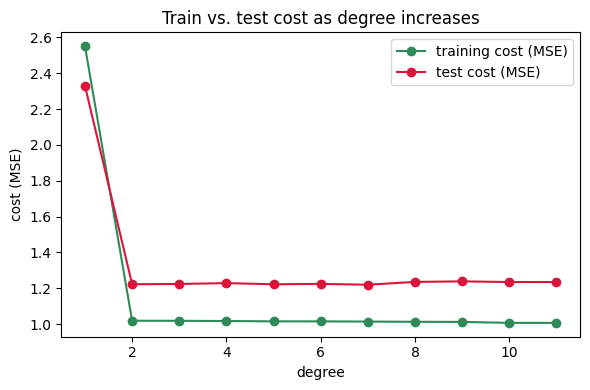

The data was generated from a degree-2 curve, and the honest sweep -- letting the TEST set
decide, not the training set -- lands right back on it.


In [50]:
plt.figure(figsize=(6,4))
plt.plot(sweep_df['degree'], sweep_df['train_mse'], 'o-', color='seagreen', label='training cost (MSE)')
plt.plot(sweep_df['degree'], sweep_df['test_mse'], 'o-', color='crimson', label='test cost (MSE)')
plt.xlabel('degree')
plt.ylabel('cost (MSE)')
plt.title('Train vs. test cost as degree increases')
plt.legend()
plt.tight_layout()
plt.show()

print("The data was generated from a degree-2 curve, and the honest sweep -- letting the TEST set")
print("decide, not the training set -- lands right back on it.")